Setup:

In [2]:
!pip install datasets sentence-transformers faiss-cpu scikit-learn numpy pandas
!pip install mmh3
!pip install gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 3.4 MB/s eta 0:00:00


In [3]:
import os, torch
import faiss
from datasets import load_dataset
import gdown, numpy as np
from collections import defaultdict, deque
import mmh3
import hashlib
import random
from tqdm import tqdm
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
import math

# Load QQP dataset
dataset = load_dataset("glue", "qqp", split="train")

# Choose subset for testing
n_sample = len(dataset)  # adjust for scale
dataset = dataset.shuffle(seed=42).select(range(n_sample))

# Convert columns to Python lists explicitly
q1_list = list(dataset["question1"])
q2_list = list(dataset["question2"])

# Combine and deduplicate
questions = list(set(q1_list + q2_list))

# Download pre-computed embeddings
url = "https://drive.google.com/uc?id=177zbL5sW2mUb4n8TVoviw7dnpyOLfhPn"
output = "X_float32.npy"
gdown.download(url, output, quiet=True)

# Load embeddings
X = np.load("X_float32.npy")
print("Embedding matrix:", X.shape)
d = X.shape[1]

print(f"Loaded {len(questions)} unique questions from QQP sample.")
print("Example:", questions[:5])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

qqp/train-00000-of-00001.parquet:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

qqp/validation-00000-of-00001.parquet:   0%|          | 0.00/3.73M [00:00<?, ?B/s]

qqp/test-00000-of-00001.parquet:   0%|          | 0.00/36.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/363846 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/40430 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/390965 [00:00<?, ? examples/s]

Embedding matrix: (493874, 384)
Loaded 493874 unique questions from QQP sample.
Example: ['During the Gilded Age, what was the difference between the Democrats and the Republicans?', 'Some useful life hacks?', 'Is it safe for an Indian Hindu to travel to Kashmir?', 'What are some examples of similes in songs?', 'Which is the best TIME or IMS for CAT in Banglore ?']


In [4]:
import matplotlib.pyplot as plt
from collections import Counter
def plot_cluster_stats(labels, title_prefix="Predicted"):
    """
    Visualizes cluster statistics similar to the HPMR code.
    Args:
        labels: Array of cluster IDs (one per item).
        title_prefix: String to add to plot titles (e.g., "MinHash", "SimHash").
    """
    # 1. Count size of each cluster
    # Filter out -1 if you use it for noise, though connected_components usually assigns all
    cluster_sizes = Counter(labels)

    # Sort clusters by size (largest first)
    sorted_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)
    cluster_ids, cluster_counts = zip(*sorted_clusters)

    # 2. Count how many clusters of each size exist
    # e.g., {Size 2: 100 clusters, Size 3: 20 clusters}
    size_distribution = Counter(cluster_counts)
    sizes, num_clusters = zip(*sorted(size_distribution.items()))

    # --- Plot 1: Cluster Size Distribution (Histogram of sizes) ---
    plt.figure(figsize=(10, 5))
    plt.bar(sizes, num_clusters, color='skyblue', edgecolor='black')
    plt.title(f"{title_prefix}: Cluster Size Distribution")
    plt.xlabel("Cluster Size (Number of Questions)")
    plt.ylabel("Frequency (Number of Clusters)")
    plt.yscale('log')  # Log scale often helps if there are many small clusters
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- Plot 2: Top 20 Largest Clusters ---
    top_k = 20
    if len(cluster_counts) > top_k:
        top_counts = cluster_counts[:top_k]
    else:
        top_counts = cluster_counts

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(top_counts)), top_counts, color='salmon', edgecolor='black')
    plt.title(f"{title_prefix}: Top {len(top_counts)} Largest Clusters")
    plt.xlabel("Cluster Rank")
    plt.ylabel("Size of Cluster")
    plt.xticks(range(len(top_counts)), [str(i+1) for i in range(len(top_counts))])
    plt.show()

    print(f"[{title_prefix}] Total clusters: {len(cluster_sizes)}")
    print(f"[{title_prefix}] Largest cluster size: {cluster_counts[0]}")

def get_cluster_representatives(cluster_labels, embeddings, texts):
    """
    Identifies the representative text for each cluster by finding the
    item closest to the cluster's semantic centroid.

    Args:
        cluster_labels: Array of cluster IDs (length N).
        embeddings: Matrix of embeddings (N x D).
        texts: List of text strings (length N).

    Returns:
        dict: {cluster_id: representative_text_string}
    """
    representatives = {}

    # Get unique cluster IDs (excluding noise if labeled -1, though connected_components usually doesn't output -1)
    unique_clusters = set(cluster_labels)

    for cid in unique_clusters:
        # Get indices of all nodes in this cluster
        indices = np.where(cluster_labels == cid)[0]

        # Skip empty or noise clusters
        if len(indices) == 0:
            continue

        # If cluster has only 1 item, that is the representative
        if len(indices) == 1:
            representatives[cid] = texts[indices[0]]
            continue

        # --- Compute Centroid ---
        # 1. Get vectors for this cluster
        cluster_vecs = embeddings[indices]

        # 2. Calculate mean vector (centroid)
        centroid = cluster_vecs.mean(axis=0)

        # 3. Normalize centroid (so dot product = cosine similarity)
        norm = np.linalg.norm(centroid)
        if norm > 0:
            centroid /= norm

        # 4. Find vector closest to centroid
        # Since vectors in 'X' (MiniLM) are usually normalized, dot product is cosine sim.
        # If X is not normalized, you might want to normalize cluster_vecs here.
        similarities = np.dot(cluster_vecs, centroid)
        best_idx_local = np.argmax(similarities)
        best_idx_global = indices[best_idx_local]

        representatives[cid] = texts[best_idx_global]

    return representatives

def save_clustering_results(questions, labels, embeddings, filename):
    """
    Saves clustering results to a CSV file with columns:
    - id: The original node ID (index in the questions list)
    - text: The question text
    - cluster_id: The ID of the cluster
    - cluster_rank: Rank of the cluster by size (0 = largest)
    - is_representative: 1 if this is the central question of the cluster, 0 otherwise
    """
    print(f"Generating CSV: {filename}...")

    # 1. Calculate Cluster Sizes and Ranks
    valid_indices = [i for i, label in enumerate(labels) if label != -1]
    valid_labels = labels[valid_indices]

    cluster_sizes = Counter(valid_labels)
    sorted_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)
    rank_map = {cid: rank for rank, (cid, _) in enumerate(sorted_clusters)}

    # 2. Prepare DataFrame Data
    n_samples = len(questions)
    df = pd.DataFrame({
        "original_id": range(n_samples),   # <--- ADDED: Original Node ID (0 to N-1)
        "text": questions,
        "pred_cluster_id": labels,
    })

    # Map ranks (assign -1 rank to noise)
    df["pred_cluster_rank"] = df["pred_cluster_id"].map(lambda x: rank_map.get(x, -1))

    # 3. Identify Representative (Semantic Centroid)
    is_rep = np.zeros(n_samples, dtype=int)

    for cid, _ in sorted_clusters:
        indices = np.where(labels == cid)[0]
        if len(indices) == 0: continue

        if len(indices) == 1:
            is_rep[indices[0]] = 1
            continue

        # Compute Centroid
        cluster_vecs = embeddings[indices]
        centroid = cluster_vecs.mean(axis=0)
        norm = np.linalg.norm(centroid)
        if norm > 0: centroid /= norm

        # Find closest question to centroid
        sims = np.dot(cluster_vecs, centroid)
        best_local_idx = np.argmax(sims)
        best_global_idx = indices[best_local_idx]

        is_rep[best_global_idx] = 1

    df["is_representative"] = is_rep

    # 4. Sort and Save
    # We sort by Rank (so largest clusters are at the top)
    df = df.sort_values(by=["pred_cluster_rank", "is_representative"], ascending=[True, False])

    df.to_csv(filename, index=False)
    print(f"✅ Saved results to: {filename}")
    return df

def evaluate_filtered(true_labels, pred_labels, edges_true, edges_pred, min_k=2, side="gt"):
    """
    side:
      - "gt":     keep nodes whose GT component size >= min_k
      - "pred":   keep nodes whose Pred component size >= min_k
      - "either": keep nodes where (GT size >= min_k) or (Pred size >= min_k)
      - "both":   keep nodes where (GT size >= min_k) and (Pred size >= min_k)
    """
    import numpy as np
    from collections import Counter
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score

    # per-node component sizes
    gt_sizes   = Counter(true_labels.tolist())
    pr_sizes   = Counter(pred_labels.tolist())
    gt_pernode = np.array([gt_sizes[c] for c in true_labels])
    pr_pernode = np.array([pr_sizes[c] for c in pred_labels])

    if side == "gt":
        mask = gt_pernode >= min_k
    elif side == "pred":
        mask = pr_pernode >= min_k
    elif side == "either":
        mask = (gt_pernode >= min_k) | (pr_pernode >= min_k)
    elif side == "both":
        mask = (gt_pernode >= min_k) & (pr_pernode >= min_k)
    else:
        mask= np.ones_like(true_labels, dtype=bool) # choose all
        side="neither"

    keep_ids = np.where(mask)[0]
    if len(keep_ids) == 0:
        print("No nodes left after filtering.")
        return

    # Remap node IDs to 0..M-1 for edge sets
    remap = -np.ones_like(mask, dtype=int)
    remap[keep_ids] = np.arange(len(keep_ids))

    def filter_edges(edges):
        out = set()
        for a,b in edges:
            ra, rb = remap[a], remap[b]
            if ra != -1 and rb != -1:
                if ra > rb: ra, rb = rb, ra
                out.add((int(ra), int(rb)))
        return out

    E_true_f = filter_edges(edges_true)
    E_pred_f = filter_edges(edges_pred)

    # Labels filtered (IDs don’t need to match sets; ARI/NMI handle arbitrary labels)
    y_true_f = true_labels[keep_ids]
    y_pred_f = pred_labels[keep_ids]

    # Pairwise
    tp = len(E_pred_f & E_true_f)
    fp = len(E_pred_f - E_true_f)
    fn = len(E_true_f - E_pred_f)
    prec  = tp / (tp + fp) if (tp + fp) else 0.0
    rec   = tp / (tp + fn) if (tp + fn) else 0.0
    f1    = 2*prec*rec / (prec+rec) if (prec+rec) else 0.0

    # Clustering
    ari = adjusted_rand_score(y_true_f, y_pred_f)
    nmi = normalized_mutual_info_score(y_true_f, y_pred_f)
    fms = fowlkes_mallows_score(y_true_f, y_pred_f)

    print(f"[Filtered side={side}, min_k={min_k}] kept nodes: {len(keep_ids)}")
    print(f"Pairwise  P={prec:.4f} R={rec:.4f} F1={f1:.4f}  (TP/FP/FN={tp}/{fp}/{fn})")
    print(f"Cluster   ARI={ari:.4f} NMI={nmi:.4f} FMS={fms:.4f}")

# ==== EXPERIMENT KNOBS ====
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"  # embed model
MAX_ROWS    = None   # None if use all row

# FAISS (IVF-IP ~ cosine) params
K_NEIGHBORS = 10
TAU         = 0.9     # cosine threshold for linking neighbors into graph
NPROBE      = 16        # IVF probes
# nlist (number of IVF cells) will be set ≈ sqrt(N) automatically

SEED = 42
random.seed(SEED); np.random.seed(SEED)


# GLUE/QQP via HuggingFace. Split has columns: question1, question2, label (1=duplicate,0=not)
ds = load_dataset("glue", "qqp")  # train/validation/test

df = ds["train"].to_pandas()[["question1","question2","label"]].dropna()
df = df.rename(columns={"label":"is_duplicate"})

if MAX_ROWS is not None and MAX_ROWS < len(df):
    df = df.sample(n=MAX_ROWS, random_state=SEED).reset_index(drop=True)

# Map each unique question to an integer ID
questions = pd.Index(pd.unique(pd.concat([df["question1"], df["question2"]], ignore_index=True)))
qid = {q: i for i, q in enumerate(questions)}
N = len(questions)
print(f"Unique questions (nodes): {N}")

# Ground-truth positive edges (dup pairs)
edges_true = set()
for q1, q2, y in df[["question1","question2","is_duplicate"]].itertuples(index=False):
    if y == 1:
        a, b = qid[q1], qid[q2]
        if a != b:
            if a > b: a, b = b, a
            edges_true.add((a,b))
# Build adjacency and connected components for ground truth
adj_true = [[] for _ in range(N)]
for a,b in edges_true:
    adj_true[a].append(b); adj_true[b].append(a)


def connected_components(adj):
    comp_id = [-1]*len(adj)
    cid = 0
    for s in range(len(adj)):
        if comp_id[s] != -1:
            continue
        dq = deque([s])
        comp_id[s] = cid
        while dq:
            u = dq.popleft()
            for v in adj[u]:
                if comp_id[v] == -1:
                    comp_id[v] = cid
                    dq.append(v)
        cid += 1
    return np.array(comp_id), cid

true_labels, n_true_comps = connected_components(adj_true)

def evaluate_method(duplicates, true_labels, edges_true, method_name="Method", csv_name="results.csv"):
    # ... (existing code to build adj_pred) ...
    edges_pred = set()
    for a, b in duplicates:
        if a == b: continue
        if a > b: a, b = b, a
        edges_pred.add((a, b))

    adj_pred = [[] for _ in range(len(X))]
    for a, b in edges_pred:
        adj_pred[a].append(b)
        adj_pred[b].append(a)

    # --- Connected components ---
    pred_labels, n_pred_comps = connected_components(adj_pred)

    print(f"Predicted {n_pred_comps} components ({len(edges_pred)} edges).")

    # --- Visualization (from previous step) ---
    plot_cluster_stats(pred_labels, title_prefix=method_name)

    # === NEW: Get and Print Representatives ===
    # We use the global 'X' (embeddings) and 'questions' (text list)
    reps = get_cluster_representatives(pred_labels, X, questions)

    print(f"\n--- {method_name} Representative Examples ---")
    # Sort by cluster size to show interesting ones first
    sizes = Counter(pred_labels)
    top_clusters = sorted(sizes.items(), key=lambda x: x[1], reverse=True)[:3]

    # --- NEW: Export CSV if requested ---
    if csv_name:
        # We access the global 'questions' list and 'X' embedding matrix
        save_clustering_results(questions, pred_labels, X, csv_name)
    # ------------------------------------

    evaluate_filtered(true_labels, pred_labels, edges_true, edges_pred, min_k=2, side="both")

    for cid, size in top_clusters:
        if size > 1: # Only show non-trivial clusters
            print(f"Cluster {cid} (Size {size}):")
            print(f"   Representative: \"{reps[cid]}\"")
            # Optional: Print a few members to verify
            # indices = np.where(pred_labels == cid)[0]
            # print(f"   Members: {[questions[i] for i in indices[:3]]} ...")
            print("")
    # ==========================================

Unique questions (nodes): 493874


In [5]:
print(pd.unique(pd.concat([df["question1"], df["question2"]], ignore_index=True)))

['How is the life of a math student? Could you describe your own experiences?'
 'How do I control my horny emotions?'
 'What causes stool color to change to yellow?' ... 'How thick is 5 mil?'
 'How does a generator work and produce current?'
 'How do I understand the difference between the Hindu calendar and the Gregorian calendar? My Hindu friend says his date of birth falls on a different day on the Hindu calendar every year. What is the difference?']


In [6]:
# Quick size histogram

sizes_true = Counter(true_labels.tolist())
hist_true = Counter(sizes_true.values())
print("Ground-truth component size histogram (size:count) [top 10]:",
      dict(sorted(hist_true.items())[:10]))

Ground-truth component size histogram (size:count) [top 10]: {1: 354909, 2: 43986, 3: 6829, 4: 2157, 5: 972, 6: 510, 7: 302, 8: 197, 9: 152, 10: 76}


Which means we have 410520 cluster, and number of clusters that have only 1 node is quite large (354909)

In [7]:
# 1️⃣ Cluster histogram by number of sentences (nodes)
cluster_sizes = Counter(true_labels)
sorted_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)
cluster_ids, cluster_counts = zip(*sorted_clusters)
print(sorted_clusters[1])

(np.int64(117), 97)


In [8]:
# 2️⃣ Histogram of cluster size frequencies
type_counts = Counter(cluster_counts)
sizes, num_clusters = zip(*sorted(type_counts.items()))

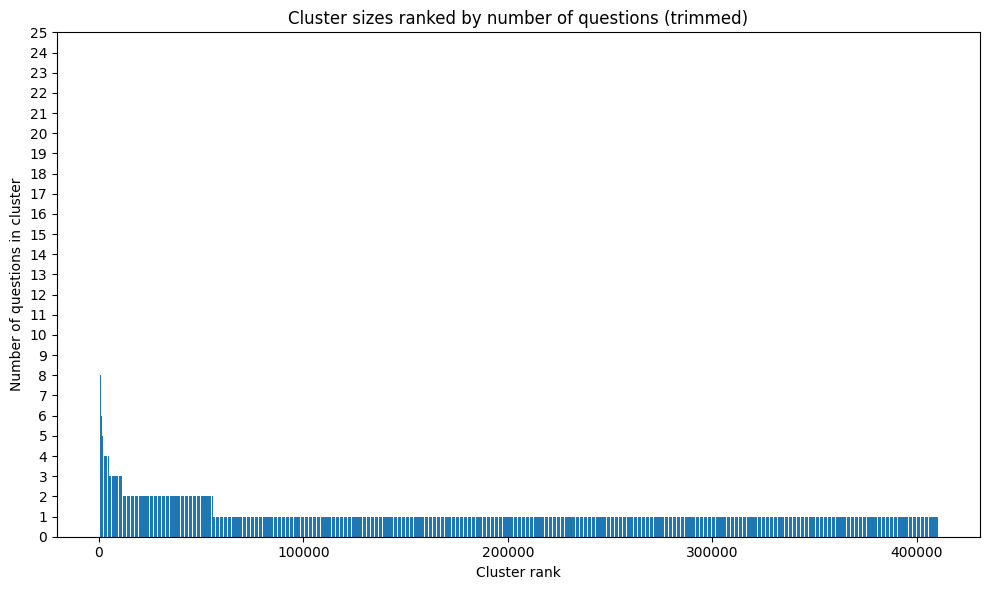

In [9]:
plt.figure(figsize=(10,6))
plt.bar(range(len(cluster_ids)), cluster_counts)
plt.title("Cluster sizes ranked by number of questions (trimmed)")
plt.xlabel("Cluster rank")
plt.ylabel("Number of questions in cluster")
plt.ylim(0, 25)   # 👈 limits y-axis for better visibility
plt.yticks(np.arange(0, 26, 1))
plt.tight_layout()
plt.show()

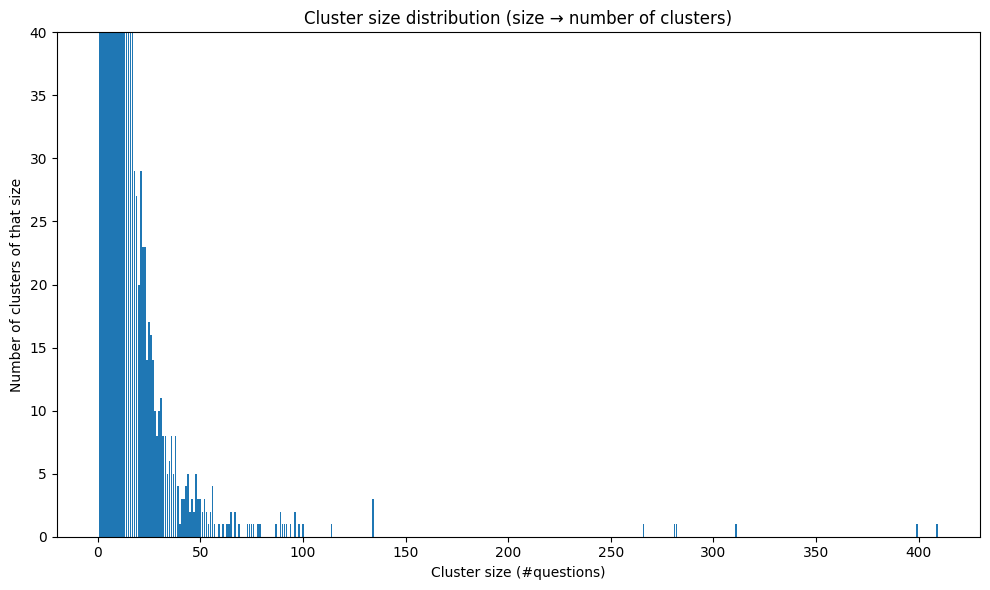

In [22]:
plt.figure(figsize=(10,6))
plt.bar(sizes, num_clusters)
plt.title("Cluster size distribution (size → number of clusters)")
plt.xlabel("Cluster size (#questions)")
plt.ylabel("Number of clusters of that size")
plt.ylim(0, 40)
plt.tight_layout()
plt.show()


In [11]:
# 3️⃣ CSV file: text grouped by cluster, clusters ranked by size
rank_map = {cid: rank for rank, (cid, _) in enumerate(sorted_clusters)}

df_out = pd.DataFrame({
    "original_id": np.arange(len(true_labels)),
    "text": [questions[i] for i in range(len(true_labels))],
    "pred_cluster_id": true_labels,
    "pred_cluster_rank": [rank_map[true_labels[i]] for i in range(len(true_labels))]
})

# ✅ Sort by cluster_rank (so clusters appear together in CSV)
df_out = df_out.sort_values(by=["pred_cluster_rank"]).reset_index(drop=True)

df_out.to_csv("qqp_clusters_grouped.csv", index=False)
print("✅ Saved: qqp_clusters_grouped.csv (grouped by cluster)")

✅ Saved: qqp_clusters_grouped.csv (grouped by cluster)


In [12]:
# nlist ~ sqrt(N) is a reasonable default
import time
start_time = time.time()

nlist = max(10, int(math.sqrt(N)))
print("nlist:", nlist)

# Quantizer + IVF Flat (no compression). Metric=IP since vectors are normalized.
quantizer = faiss.IndexFlatIP(d)
index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)

# Train IVF on a sample
train_sz = min(20000, N)
train_ix = np.random.choice(N, size=train_sz, replace=False)
index.train(X[train_ix])



index.add(X)
index.nprobe = 16
print("Index ntotal:", index.ntotal)



K = K_NEIGHBORS
D, I = index.search(X, K+1)   # rank 0 is self

# Build predicted edge set via cosine threshold TAU
edges_pred = set()
for i in range(N):
    for sim, j in zip(D[i], I[i]):
        if j < 0 or j == i:
            continue
        if sim >= TAU:
            a, b = (i,j) if i < j else (j,i)
            edges_pred.add((a,b))

print("Predicted edges:", len(edges_pred))

# Predicted components
adj_pred = [[] for _ in range(N)]
for a,b in edges_pred:
    adj_pred[a].append(b); adj_pred[b].append(a)

pred_labels, n_pred_comps = connected_components(adj_pred)
total_time = time.time() - start_time
print(f"\n=== TOTAL TIME FAISS: {total_time:.2f}s ===")

print(f"Predicted components: {n_pred_comps}")
sizes_pred = Counter(pred_labels.tolist())
hist_pred = Counter(sizes_pred.values())
print("Predicted component size histogram (size:count) [top 10]:",
      dict(sorted(hist_pred.items())[:10]))

nlist: 702
Index ntotal: 493874
Predicted edges: 157925

=== TOTAL TIME FAISS: 1150.71s ===
Predicted components: 402278
Predicted component size histogram (size:count) [top 10]: {1: 354607, 2: 34900, 3: 6399, 4: 2458, 5: 1200, 6: 697, 7: 464, 8: 304, 9: 187, 10: 143}


In [23]:
def evaluate_filtered(true_labels, pred_labels, edges_true, edges_pred, min_k=2, side="gt"):
    """
    Evaluates clustering metrics (ARI, NMI, FMS, Cluster P/R) and pairwise metrics (P/R/F1)
    after filtering nodes based on the size of their true or predicted clusters.

    side:
      - "gt":     keep nodes whose GT component size >= min_k
      - "pred":   keep nodes whose Pred component size >= min_k
      - "either": keep nodes where (GT size >= min_k) or (Pred size >= min_k)
      - "both":   keep nodes where (GT size >= min_k) and (Pred size >= min_k)
    """

    import numpy as np
    from collections import Counter
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
    from sklearn.metrics.cluster import contingency_matrix

    # 1. Determine which nodes to keep based on cluster size (Filtering)
    gt_sizes   = Counter(true_labels.tolist())
    pr_sizes   = Counter(pred_labels.tolist())
    gt_pernode = np.array([gt_sizes[c] for c in true_labels])
    pr_pernode = np.array([pr_sizes[c] for c in pred_labels])

    if side == "gt":
        mask = gt_pernode >= min_k
    elif side == "pred":
        mask = pr_pernode >= min_k
    elif side == "either":
        mask = (gt_pernode >= min_k) | (pr_pernode >= min_k)
    elif side == "both":
        mask = (gt_pernode >= min_k) & (pr_pernode >= min_k)
    else:
        mask = np.ones_like(true_labels, dtype=bool) # choose all
        side = "none"

    keep_ids = np.where(mask)[0]
    if len(keep_ids) == 0:
        print("No nodes left after filtering.")
        return

    # 2. Filter Edge Sets (for Pairwise Metrics)
    remap = -np.ones_like(mask, dtype=int)
    remap[keep_ids] = np.arange(len(keep_ids))

    def filter_edges(edges):
        out = set()
        for a, b in edges:
            ra, rb = remap[a], remap[b]
            if ra != -1 and rb != -1:
                # Ensure canonical order
                if ra > rb: ra, rb = rb, ra
                out.add((int(ra), int(rb)))
        return out

    E_true_f = filter_edges(edges_true)
    E_pred_f = filter_edges(edges_pred)

    # 3. Calculate Pairwise Metrics (based on edges)
    tp = len(E_pred_f & E_true_f)
    fp = len(E_pred_f - E_true_f)
    fn = len(E_true_f - E_pred_f)

    prec  = tp / (tp + fp) if (tp + fp) else 0.0
    rec   = tp / (tp + fn) if (tp + fn) else 0.0
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0

    # 4. Calculate Cluster Metrics (based on labels)
    y_true_f = true_labels[keep_ids]
    y_pred_f = pred_labels[keep_ids]

    # --- Cluster Precision/Recall Calculation (Pair Counting) ---

    # Generate the Contingency Matrix
    cm = contingency_matrix(y_true_f, y_pred_f, sparse=True)
    N  = len(y_true_f)

    # N11: Number of agreeing pairs (same cluster in both)
    # N11 = 0.5 * (sum of squares of CM elements - N)
    sum_of_squares = (cm.data**2).sum()
    N_11 = 0.5 * (sum_of_squares - N)

    # N_true_same: Total pairs in the same true cluster (N11 + N10)
    N_true_same = 0.5 * (np.sum(np.array(cm.sum(axis=1))**2) - N)

    # N_pred_same: Total pairs in the same predicted cluster (N11 + N01)
    N_pred_same = 0.5 * (np.sum(np.array(cm.sum(axis=0))**2) - N)

    # Cluster Metrics
    cl_prec = N_11 / N_pred_same if N_pred_same else 0.0
    cl_rec  = N_11 / N_true_same if N_true_same else 0.0

    # Scikit-learn Cluster Metrics
    ari = adjusted_rand_score(y_true_f, y_pred_f)
    nmi = normalized_mutual_info_score(y_true_f, y_pred_f)
    fms = fowlkes_mallows_score(y_true_f, y_pred_f) # Should be sqrt(cl_prec * cl_rec)

    # 5. Output Results
    print(f"--- Evaluation Results (side={side}, min_k={min_k}) ---")
    print(f"Nodes Kept: {len(keep_ids)}")
    print("-" * 35)
    print(f"Pairwise Metrics (Edges):")
    print(f"  P={prec:.4f} R={rec:.4f} F1={f1:.4f}  (TP/FP/FN={tp}/{fp}/{fn})")
    print("-" * 35)
    print(f"Clustering Metrics (Labels):")
    print(f"  Cluster P={cl_prec:.4f} R={cl_rec:.4f} FMS={fms:.4f}")
    print(f"  ARI={ari:.4f} NMI={nmi:.4f}")
    print("-" * 35)

    return

evaluate_filtered(true_labels, pred_labels, edges_true, edges_pred, min_k=2, side="gt")

--- Evaluation Results (side=gt, min_k=2) ---
Nodes Kept: 138965
-----------------------------------
Pairwise Metrics (Edges):
  P=0.6526 R=0.4196 F1=0.5108  (TP/FP/FN=56381/30008/77997)
-----------------------------------
Clustering Metrics (Labels):
  Cluster P=0.3273 R=0.4094 FMS=0.3661
  ARI=0.3638 NMI=0.9682
-----------------------------------


In [14]:
# 1️⃣ Cluster histogram by number of sentences (nodes)
cluster_sizes = Counter(pred_labels)
sorted_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)
cluster_ids, cluster_counts = zip(*sorted_clusters)

# 2️⃣ Histogram of cluster size frequencies
type_counts = Counter(cluster_counts)
sizes, num_clusters = zip(*sorted(type_counts.items()))

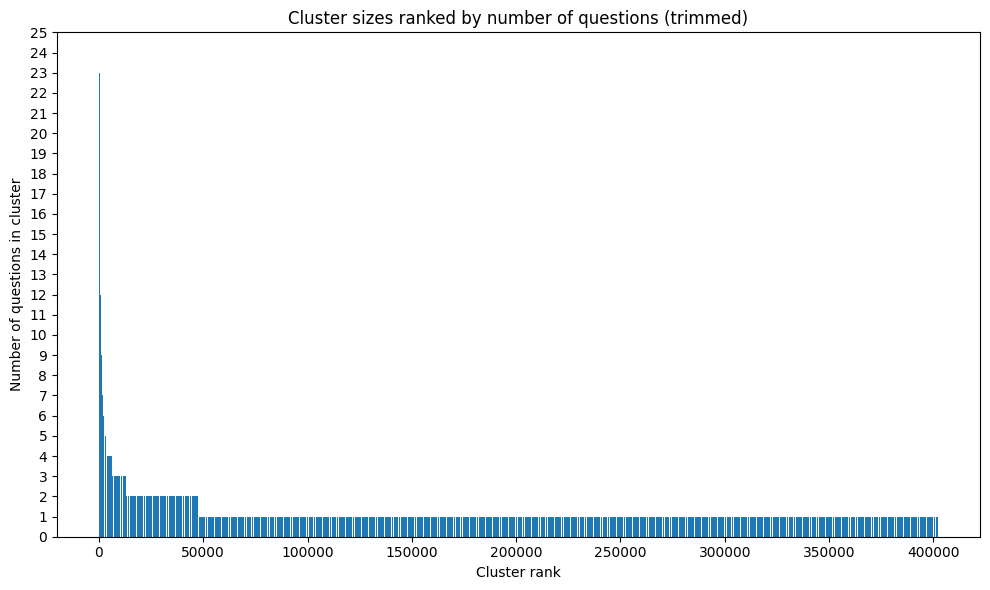

In [15]:
plt.figure(figsize=(10,6))
plt.bar(range(len(cluster_ids)), cluster_counts)
plt.title("Cluster sizes ranked by number of questions (trimmed)")
plt.xlabel("Cluster rank")
plt.ylabel("Number of questions in cluster")
plt.ylim(0, 25)   # 👈 limits y-axis for better visibility
plt.yticks(np.arange(0, 26, 1))
plt.tight_layout()
plt.show()

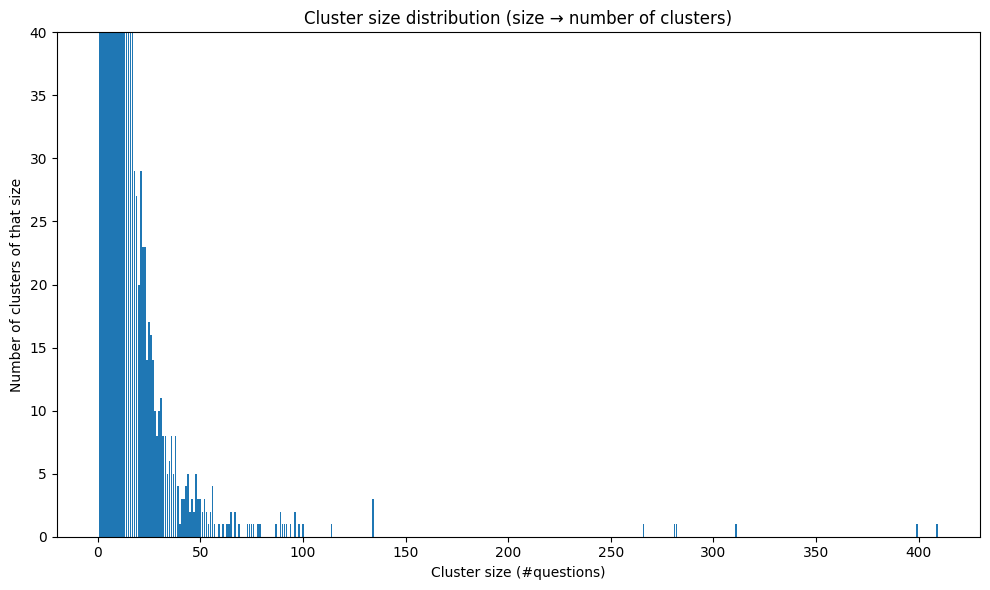

In [16]:
plt.figure(figsize=(10,6))
plt.bar(sizes, num_clusters)
plt.title("Cluster size distribution (size → number of clusters)")
plt.xlabel("Cluster size (#questions)")
plt.ylabel("Number of clusters of that size")
plt.ylim(0, 40)
plt.tight_layout()
plt.show()

In [17]:
# 1️⃣ Build size & rank mapping as before
pred_cluster_sizes = Counter(pred_labels)
sorted_pred_clusters = sorted(pred_cluster_sizes.items(), key=lambda x: x[1], reverse=True)
rank_map_pred = {cid: rank for rank, (cid, _) in enumerate(sorted_pred_clusters)}

# 2️⃣ Prepare DataFrame
df_pred = pd.DataFrame({
    "original_id": np.arange(len(true_labels)),
    "text": questions,
    "pred_cluster_id": pred_labels,
    "pred_cluster_rank": [rank_map_pred[c] for c in pred_labels],
})

# 3️⃣ Compute representative sentence per cluster (semantic mean)
mean_semantic_remain = np.zeros(len(pred_labels), dtype=int)

for cid in pred_cluster_sizes.keys():
    idx = np.where(pred_labels == cid)[0]
    if len(idx) == 0:
        continue
    if len(idx) == 1:
        mean_semantic_remain[idx[0]] = 1
        continue

    # Compute cluster mean vector
    centroid = X[idx].mean(axis=0)
    centroid /= np.linalg.norm(centroid) + 1e-8  # normalize

    # Compute cosine similarity to centroid
    sims = (X[idx] @ centroid)
    rep_idx = idx[np.argmax(sims)]   # most central sentence
    mean_semantic_remain[rep_idx] = 1

# 4️⃣ Add to dataframe
df_pred["is_representative"] = mean_semantic_remain

# 5️⃣ Sort by cluster rank
df_pred = df_pred.sort_values(
    by=["pred_cluster_rank", "is_representative"],
    ascending=[True, False]
).reset_index(drop=True)

# 6️⃣ Save CSV
df_pred.to_csv("qqp_pred_clusters_faiss_grouped.csv", index=False)
print("✅ Saved qqp_pred_clusters_faiss_grouped.csv (with mean_semantic_remain)")


✅ Saved qqp_pred_clusters_faiss_grouped.csv (with mean_semantic_remain)


Minhash:


[MinHash] Process Started at: 00:00:21


[MinHash] Completed. Total time: 69.73 seconds
MinHash duplicates found: 80948
Predicted 481086 components (80948 edges).


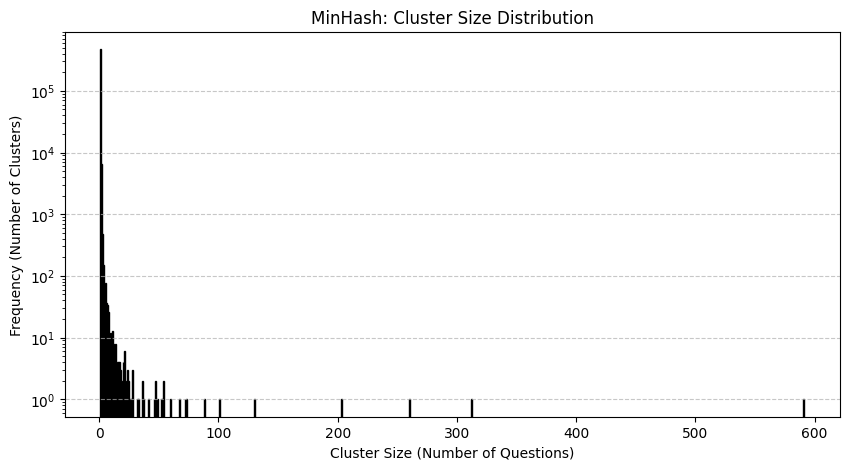

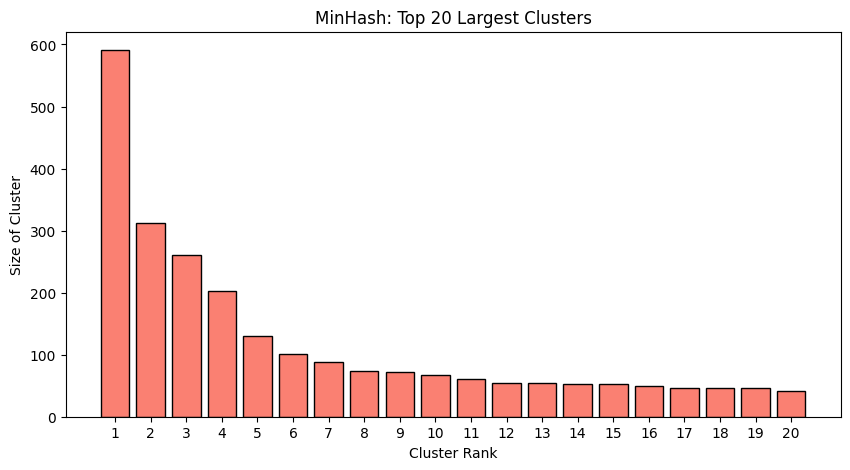

[MinHash] Total clusters: 481086
[MinHash] Largest cluster size: 591

--- MinHash Representative Examples ---
Generating CSV: results_minhash.csv...
✅ Saved results to: results_minhash.csv
--- Evaluation Results (side=both, min_k=2) ---
Nodes Kept: 9454
-----------------------------------
Pairwise Metrics (Edges):
  P=0.8177 R=0.7696 F1=0.7929  (TP/FP/FN=4131/921/1237)
-----------------------------------
Clustering Metrics (Labels):
  Cluster P=0.7882 R=0.8312 FMS=0.8094
  ARI=0.8091 NMI=0.9893
-----------------------------------
Cluster 746 (Size 591):
   Representative: "What are some things new employees should know going into their first day at Assurant?"

Cluster 79 (Size 312):
   Representative: "Do employees at Unit have a good work-life balance? Does this differ across positions and departments?"

Cluster 1615 (Size 260):
   Representative: "What universities does Target recruit new grads from? What majors are they looking for?"



In [24]:
import re
def clean(text):
    # Lowercase, remove punctuation, remove extra whitespace
    return re.sub(r'[^\w\s]', '', text.lower()).strip()

# generate k-shingles (character-based)
def get_shingles(text, k=5):
    text = clean(text)
    text = text.lower().replace(" ", "")
    return {text[i:i+k] for i in range(max(1, len(text) - k + 1))}

# create MinHash signature for a set of shingles
def create_minhash(shingles, A, B, max_hash):
    if not shingles:
        return np.zeros_like(A)
    hashes = np.array([hash(s) % max_hash for s in shingles], dtype=np.uint32)
    sigs = np.min((A[:, None] * hashes + B[:, None]) % max_hash, axis=1)
    return sigs

import time
from datetime import datetime

def deduplicate_minhash(texts, num_perm=64, threshold=0.8, bands=8):
    t0 = time.time()
    print(f"\n[MinHash] Process Started at: {datetime.fromtimestamp(t0).strftime('%H:%M:%S')}")

    # --- Existing Logic ---
    max_hash = (1 << 32) - 1
    A = np.random.randint(1, max_hash, size=num_perm, dtype=np.uint32)
    B = np.random.randint(0, max_hash, size=num_perm, dtype=np.uint32)

    signatures = np.zeros((len(texts), num_perm), dtype=np.uint32)
    for i, text in enumerate(tqdm(texts, desc="MinHash Signatures", leave=False)):
        shingles = get_shingles(text)
        signatures[i] = create_minhash(shingles, A, B, max_hash)

    rows_per_band = num_perm // bands
    buckets = defaultdict(list)
    for i in tqdm(range(len(texts)), desc="LSH Bucketing", leave=False):
        sig = signatures[i]
        for b in range(bands):
            start, end = b * rows_per_band, (b + 1) * rows_per_band
            band_hash = hashlib.sha1(sig[start:end].tobytes()).hexdigest()
            buckets[(b, band_hash)].append(i)

    candidates = set()
    for group in tqdm(buckets.values(), desc="Bucket comparisons", leave=False):
        if len(group) < 2: continue
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                a, b = group[i], group[j]
                sim = np.mean(signatures[a] == signatures[b])
                if sim >= threshold:
                    candidates.add((min(a, b), max(a, b)))

    duplicates = list(candidates)

    # --- Timing Output ---
    elapsed = time.time() - t0
    print(f"[MinHash] Completed. Total time: {elapsed:.2f} seconds")
    return duplicates

dup_minhash = deduplicate_minhash(questions, bands=8)
print(f"MinHash duplicates found:", len(dup_minhash))

if dup_minhash:
    evaluate_method(
        dup_minhash,
        true_labels,
        edges_true,
        method_name="MinHash",
        csv_name="results_minhash.csv"  # <--- Export here
    )

Simhash:


[SimHash] Process Started at: 00:12:57


[SimHash] Completed. Total time: 16.71 seconds
SimHash duplicates: 12830
Predicted 482607 components (12830 edges).


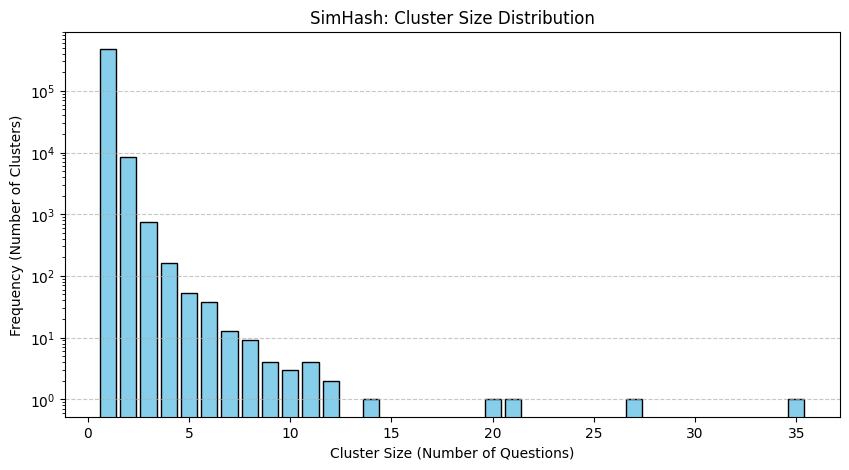

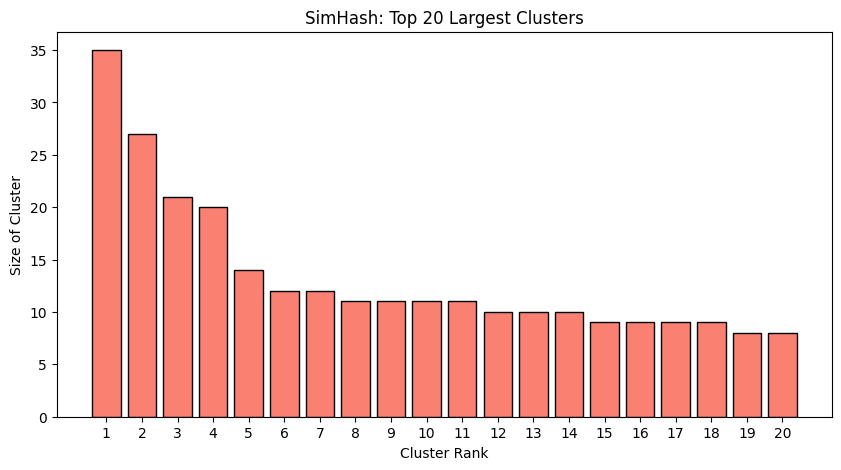

[SimHash] Total clusters: 482607
[SimHash] Largest cluster size: 35

--- SimHash Representative Examples ---
Generating CSV: results_simhash.csv...
✅ Saved results to: results_simhash.csv
--- Evaluation Results (side=both, min_k=2) ---
Nodes Kept: 16171
-----------------------------------
Pairwise Metrics (Edges):
  P=0.8204 R=0.7553 F1=0.7865  (TP/FP/FN=7042/1542/2282)
-----------------------------------
Clustering Metrics (Labels):
  Cluster P=0.8449 R=0.7165 FMS=0.7781
  ARI=0.7754 NMI=0.9895
-----------------------------------
Cluster 693 (Size 35):
   Representative: "Which is a suitable inpatient drug and alcohol rehab center near Cook County GA?"

Cluster 16899 (Size 27):
   Representative: "Which is a good inpatient drug and alcohol rehab center near Wheeler County GA?"

Cluster 2862 (Size 21):
   Representative: "Which is a suitable solar panel installation provider near Sunnyvale, California CA?"



In [25]:
def hamming_distance(a, b):
    return np.count_nonzero(a ^ b)

def simhash_matrix(X: np.ndarray, nbits=64, seed=42) -> np.ndarray:
    rng = np.random.RandomState(seed)
    rand_proj = rng.randn(X.shape[1], nbits)
    proj = np.dot(X, rand_proj) > 0
    return proj.astype(np.uint8)

def deduplicate_simhash(X: np.ndarray, nbits=64, threshold=3, prefix=16):
    t0 = time.time()
    print(f"\n[SimHash] Process Started at: {datetime.fromtimestamp(t0).strftime('%H:%M:%S')}")

    # --- Existing Logic ---
    fingerprints = simhash_matrix(X, nbits=nbits)
    N = fingerprints.shape[0]
    ints = [int("".join(map(str, row.tolist())), 2) for row in fingerprints]

    buckets = defaultdict(list)
    for i, val in tqdm(enumerate(ints), total=N, desc="Bucketing", leave=False):
        bucket_id = val >> (nbits - prefix)
        buckets[bucket_id].append(i)

    duplicates = []
    for group in tqdm(buckets.values(), desc="Comparing", leave=False):
        if len(group) < 2: continue
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                dist = hamming_distance(fingerprints[group[i]], fingerprints[group[j]])
                if dist <= threshold:
                    duplicates.append((group[i], group[j]))

    # --- Timing Output ---
    elapsed = time.time() - t0
    print(f"[SimHash] Completed. Total time: {elapsed:.2f} seconds")
    return duplicates

dup_simhash = deduplicate_simhash(X)
print("SimHash duplicates:", len(dup_simhash))
if dup_simhash:
    evaluate_method(
        dup_simhash,
        true_labels,
        edges_true,
        method_name="SimHash",
        csv_name="results_simhash.csv"  # <--- Export here
    )


Bloom filter:

In [20]:
import mmh3
import numpy as np
from tqdm import tqdm

class BloomFilter:
    def __init__(self, n_items: int, fp_rate: float = 0.01):
        """
        Initialize a Bloom Filter with optimal bit-array size and hash count.

        Args:
            n_items: Estimated number of items to store.
            fp_rate: Desired false positive probability (default 0.01).
        """
        # Calculate optimal size (m) and hash count (k)
        self.size = int(-(n_items * np.log(fp_rate)) / (np.log(2) ** 2))
        self.hash_count = int((self.size / n_items) * np.log(2))

        # Initialize bit array (using boolean for simplicity in simulation)
        # Note: In production with tight RAM, use the 'bitarray' library.
        self.bit_array = np.zeros(self.size, dtype=bool)

        self.n_items_added = 0
        self.fp_rate_target = fp_rate

    def _get_hash_indices(self, item: str):
        """
        Generate k hash indices using Double Hashing (Kirsch-Mitzenmacher).
        Requires only 2 hash computations instead of k.
        """
        # Compute two distinct hash values
        h1 = mmh3.hash(item, seed=42)
        h2 = mmh3.hash(item, seed=101)

        # Generate k indices using linear combination
        indices = []
        for i in range(self.hash_count):
            idx = (h1 + i * h2) % self.size
            indices.append(idx)
        return indices

    def add(self, item: str):
        """Add an item to the Bloom Filter."""
        for idx in self._get_hash_indices(item):
            self.bit_array[idx] = True
        self.n_items_added += 1

    def check(self, item: str) -> bool:
        """Check if an item exists (probabilistic)."""
        return all(self.bit_array[idx] for idx in self._get_hash_indices(item))

def deduplicate_bloom_optimized(texts: list, fp_rate: float = 0.01):
    """
    Run deduplication using the improved BloomFilter.
    Returns the unique items and a list of detected duplicates.
    """
    t0 = time.time()
    print(f"\n[BloomFilter] Process Started at: {datetime.fromtimestamp(t0).strftime('%H:%M:%S')}")
    bf = BloomFilter(n_items=len(texts), fp_rate=fp_rate)

    unique_texts = []
    duplicates = []

    # We maintain a 'seen' set ONLY to track false positives for evaluation purposes.
    # In a real streaming scenario, you wouldn't have memory for 'seen_ground_truth'.
    seen_ground_truth = set()
    false_positives = 0

    for text in tqdm(texts, desc="BloomFilter Processing"):
        # 1. Check if it's likely already in the set
        if bf.check(text):
            # It might be a duplicate
            if text in seen_ground_truth:
                duplicates.append(text)
            else:
                # Filter says "Yes", but Truth says "No" -> False Positive
                false_positives += 1
                unique_texts.append(text) # It was actually new, so we keep it
                seen_ground_truth.add(text)
                bf.add(text) # Add it so we find it next time
        else:
            # Definitely not in the set
            bf.add(text)
            seen_ground_truth.add(text)
            unique_texts.append(text)

    # --- Statistics ---
    total = len(texts)
    actual_fp_rate = false_positives / total if total > 0 else 0

    print(f"\n=== Bloom Filter Stats ===")
    elapsed = time.time() - t0
    print(f"[BloomFilter] Completed. Total time: {elapsed:.2f} seconds")
    print(f"Capacity (n): {len(texts)}")
    print(f"Bit Array Size (m): {bf.size} bits")
    print(f"Hash Functions (k): {bf.hash_count}")
    print(f"False Positives: {false_positives}")
    print(f"Empirical FP Rate: {actual_fp_rate:.6f}")

    return unique_texts, duplicates

    # Assuming 'sample_questions' is your list of strings
unique_questions, dups = deduplicate_bloom_optimized(questions, fp_rate=0.01)

print(f"Found {len(dups)} duplicates.")


[BloomFilter] Process Started at: 22:58:23


BloomFilter Processing: 100%|██████████| 493874/493874 [00:04<00:00, 111760.65it/s]


=== Bloom Filter Stats ===
[BloomFilter] Completed. Total time: 4.43 seconds
Capacity (n): 493874
Bit Array Size (m): 4733811 bits
Hash Functions (k): 6
False Positives: 897
Empirical FP Rate: 0.001816
Found 0 duplicates.
